In [1]:
# Maybe also look at changes to the proportion of events falling onto soils with different properties?

In [2]:
import os
import sys
import re
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm

from Functions_AnalyseResults import partial_r2_for_catchment, plot_with_best_fit_line

sys.path.append('../ProcessEvents/')
from config import CATCHMENT_LOOKUP_DICT, OUT_DIR # MOLLY_DIR_FF, RAINFALL_CSV_DIR, ENSEMBLE_MEMBERS, , CATCHMENTS

## Get a list of catchments which have flood outputs and rainfall detail outputs

In [3]:
all_catchments = set(CATCHMENT_LOOKUP_DICT.keys())

catchments_with_flood_output = []
for catchment_num in all_catchments:
    catchment_name = CATCHMENT_LOOKUP_DICT[catchment_num]
    fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails/Catchment_{catchment_num}/{catchment_name}.pkl"
    flood_fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/PluvialResults/5km_total/Catchment_{catchment_num}/Ens01_{catchment_num}/10cm/flooded_area_5km_total_Ens01_{catchment_num}_10cm.nc"
        
    if os.path.isfile(flood_fp) and os.path.isfile(fp):
        catchments_with_flood_output.append(catchment_num)
print(len(catchments_with_flood_output))

113


### Join together results for all these catchments, remove mismatched rows, add a catchment number flag

In [4]:
rainfall_events_all = []
for catchment_num in catchments_with_flood_output:
    catchment_name = CATCHMENT_LOOKUP_DICT[catchment_num]
    fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails/Catchment_{catchment_num}/{catchment_name}.pkl"
    rainfall_events = pd.read_pickle(fp)
    rainfall_events_complete = rainfall_events[rainfall_events['mismatch']!=True].copy()
    rainfall_events['catchment_num'] = catchment_num
    # print(f"Catchment {catchment_num} has {len(rainfall_events)}, of which {len(rainfall_events) - len(rainfall_events_complete)} are mismatched")
    rainfall_events_all.append(rainfall_events) 
rainfall_events_all_df = pd.concat(rainfall_events_all, ignore_index=True)    

In [5]:
rainfall_events_all_df = rainfall_events_all_df[rainfall_events_all_df['max_precip']<130].copy()

In [6]:
rainfall_events_all_df['HC_status'] = pd.cut(rainfall_events_all_df['hc_at_peak'],
    bins=[-float('inf'), 0.15, 1.1, 3, float('inf')],labels=['D', 'C', 'B', 'A'], right=False, include_lowest=True)

</div>

<div style="background-color: #f0faf0; border: 1px solid black; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

## Getting spatial data


</div>

In [6]:
regions_shp = "/scratch/hydro5/users/la17355/FUTURE-FLOOD/Results/Pluvial/v4/plots/most_exposed_events_visualisation/by_region/ukcp18-uk-land-region-hires.shp"
regions_df = gpd.read_file(regions_shp)

In [7]:
rainfall_events_all_df = gpd.GeoDataFrame(rainfall_events_all_df, geometry=gpd.points_from_xy(rainfall_events_all_df['x_coord'],
                                                                                              rainfall_events_all_df['y_coord']), crs=regions_df.crs)
rainfall_events_all_df = gpd.sjoin(rainfall_events_all_df, regions_df[['geometry', 'geo_region']], how='left', predicate='within')

</div>

<div style="background-color: #f0faf0; border: 1px solid black; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

## XXXXXX

</div>

In [21]:
q1, q2 = rainfall_events_all_df['mean_sm_2_before_event'].quantile([0.33, 0.66])

def add_sm_bin(df, col='mean_sm_2_before_event'):
    df = df.copy()
    df['sm_bin'] = pd.cut(
        df[col],
        bins=[-np.inf, q1, q2, np.inf],
        labels=['dry', 'medium', 'wet']
    )
    return df

from sklearn.linear_model import LinearRegression

results = []

for hc_class, df_hc in rainfall_events_all_df.groupby('HC_status'):
    
    df_hc = add_sm_bin(df_hc)
    
    slopes = {}
    
    for sm_bin in ['dry', 'wet']:
        sub = df_hc[df_hc['sm_bin'] == sm_bin].dropna(
            subset=['max_precip', '10cm_area'])
        
        if len(sub) < 5:
            slopes[sm_bin] = np.nan
            continue
        
        X = sub[['max_precip']].values
        y = sub['10cm_area'].values
        
        reg = LinearRegression().fit(X, y)
        slopes[sm_bin] = reg.coef_[0]  # slope
    
    sensitivity = slopes['wet'] - slopes['dry']
    
    results.append({
        'HC': hc_class,
        'slope_dry': slopes['dry'],
        'slope_wet': slopes['wet'],
        'sensitivity': sensitivity
    })

sens_df = pd.DataFrame(results)

/tmp/ipykernel_1815077/432906003.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for hc_class, df_hc in rainfall_events_all_df.groupby('HC_status'):


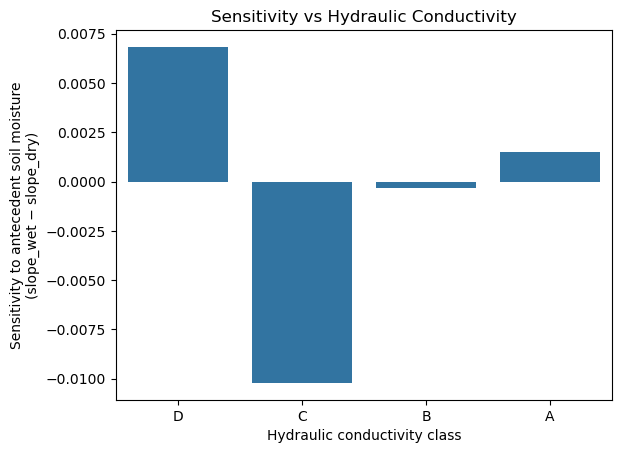

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=sens_df, x='HC', y='sensitivity')

plt.ylabel('Sensitivity to antecedent soil moisture\n(slope_wet − slope_dry)')
plt.xlabel('Hydraulic conductivity class')
plt.title('Sensitivity vs Hydraulic Conductivity')

plt.show()

/tmp/ipykernel_1815077/1770966886.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for hc_class, df_hc in rainfall_events_all_df.groupby('HC_status'):


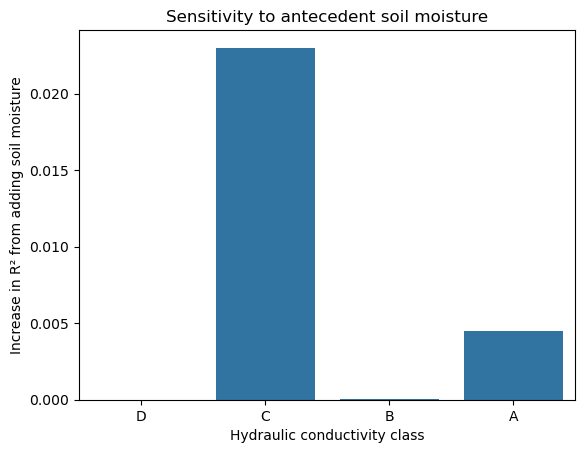

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

results = []

for hc_class, df_hc in rainfall_events_all_df.groupby('HC_status'):
    
    df_hc = df_hc.dropna(subset=[
        'max_precip', '10cm_area', 'mean_sm_2_before_event'
    ])
    
    if len(df_hc) < 10:
        continue

    # ------------------
    # Model 1: rainfall only
    # ------------------
    X1 = df_hc[['max_precip']].values
    y  = df_hc['10cm_area'].values
    
    model1 = LinearRegression().fit(X1, y)
    r2_1 = model1.score(X1, y)

    # ------------------
    # Model 2: rainfall + SM
    # ------------------
    X2 = df_hc[['max_precip', 'mean_sm_2_before_event']].values
    
    model2 = LinearRegression().fit(X2, y)
    r2_2 = model2.score(X2, y)

    # ------------------
    # Sensitivity metric
    # ------------------
    delta_r2 = r2_2 - r2_1

    results.append({
        'HC_status': hc_class,
        'r2_rain': r2_1,
        'r2_rain_sm': r2_2,
        'delta_r2': delta_r2
    })

sens_df = pd.DataFrame(results)

import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=sens_df, x='HC_status', y='delta_r2')

plt.ylabel('Increase in R² from adding soil moisture')
plt.xlabel('Hydraulic conductivity class')
plt.title('Sensitivity to antecedent soil moisture')

plt.show()

In [35]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

results = []

for hc_class, df_hc in rainfall_events_all_df.groupby('HC_status'):
    
    df_hc = df_hc.dropna(subset=[
        'max_precip', '10cm_area', 'mean_sm_2_before_event'
    ])
    
    if len(df_hc) < 20:
        continue

    y = df_hc['10cm_area'].values
    
    # ------------------
    # Model 1: rainfall only
    # ------------------
    X1 = df_hc[['max_precip']].values
    
    rf1 = RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        random_state=42
    )
    
    r2_1 = cross_val_score(rf1, X1, y, cv=5, scoring='r2').mean()

    # ------------------
    # Model 2: rainfall + SM
    # ------------------
    X2 = df_hc[['max_precip', 'mean_sm_2_before_event']].values
    
    rf2 = RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        random_state=42
    )
    
    r2_2 = cross_val_score(rf2, X2, y, cv=5, scoring='r2').mean()

    # ------------------
    # Sensitivity metric
    # ------------------
    delta_r2 = r2_2 - r2_1

    results.append({
        'HC': hc_class,
        'r2_rain': r2_1,
        'r2_rain_sm': r2_2,
        'delta_r2': delta_r2
    })

rf_sens_df = pd.DataFrame(results)

/tmp/ipykernel_1815077/538126715.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for hc_class, df_hc in rainfall_events_all_df.groupby('HC_status'):
